# Summary 

### References

* https://github.com/llnl/Wintap-Analytics/tree/main/2025-acme4-explore
* https://gdo168.llnl.gov/
* https://gdo168.llnl.gov/data/newdocs/datadict/

Download:
https://gdo168.llnl.gov/data/ACME4/stdview-20240819-20240923/process_file.parquet

In [1]:
%%time
import io
import logging as lg
import numpy as np
import os
import pandas as pd
import re
from collections import Counter
import warnings
import igraph as ig

# Modelling
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay, roc_curve, auc
from sklearn.model_selection import train_test_split
from sklearn.inspection import permutation_importance

# Visualisation
import matplotlib.pyplot as plt

## our matching algorithm
import igraph_io as igio
import fast_match as fm  ## fast version

CPU times: user 1.98 s, sys: 685 ms, total: 2.67 s
Wall time: 1.87 s


# Exploring the files


In [2]:
## the table can be found here: https://gdo168.llnl.gov/data/ACME4/stdview-20240819-20240923/
files = pd.read_parquet("Data/process_file.parquet")


In [3]:
files.columns

Index(['agent_id', 'Hostname', 'pid_hash', 'process_name', 'file_id',
       'file_hash', 'filename', 'activity_type', 'bytes_requested',
       'event_count', 'num_raw_rows', 'first_seen', 'last_seen', 'min_event',
       'max_event'],
      dtype='object')

In [4]:
files[['pid_hash', 'process_name', 'filename']].head(10)

,pid_hash,process_name,filename
0,6807D0BE6243F8A5D72EC3123D43EADA,ntoskrnl.exe,c:\windows\system32\samcli.dll
1,6807D0BE6243F8A5D72EC3123D43EADA,ntoskrnl.exe,c:\windows\temp
2,6807D0BE6243F8A5D72EC3123D43EADA,ntoskrnl.exe,c:\programdata\wintap\logs\wintap.log
3,B696A80670588C5193175908523F8068,ntoskrnl.exe,c:\$logfile
4,FC2EC18B2ECC85580CFD8287B0A85E5A,mergehelper.exe,c:\program files\dotnet\shared\microsoft.netco...
5,3FB20655DD22849704B642875DC0D05B,mergehelper.exe,c:\program files\wintap\mergertool\mergehelper...
6,7110B28B051CE154CBBCD53019698327,mergehelper.exe,c:\programdata\wintap\parquet\merged\registry_...
7,B696A80670588C5193175908523F8068,ntoskrnl.exe,c:\programdata\wintap\parquet\tcpconnection_se...
8,52F5A3C1300B1925E46C4B7570BE05F6,svchost.exe,c:\windows\servicestate\eventlog\data\lastaliv...
9,FA7421BABB3A087B49EEEC700513D79A,ntoskrnl.exe,c:\windows\servicing\packages\microsoft-window...


In [5]:
## all filepaths
Files = files.filename.tolist()
print(len(Files),'filepaths')
## unique filepaths
Files = list(set(Files))
print(len(Files),'unique filepaths')


9343199 filepaths
2653580 unique filepaths


In [6]:
S = [f.split('\\') for f in Files]
print('first item:',Counter([s[0] for s in S]))
S = [s[1:] for s in S]
Counter([len(s) for s in S])


first item: Counter({'c:': 2652025, '': 1552, 'f:': 1, 'e:': 1, 'd:': 1})


Counter({9: 802886,
         8: 799663,
         5: 252146,
         11: 222313,
         6: 173121,
         10: 117264,
         7: 97925,
         13: 52192,
         12: 42335,
         14: 32314,
         4: 28058,
         3: 11312,
         15: 8834,
         16: 7911,
         17: 1965,
         18: 1401,
         2: 898,
         20: 777,
         19: 168,
         1: 71,
         21: 17,
         23: 5,
         22: 4})

# (1) Examples of matches given a specific path

There are many distinct paths, and many partial matches between paths.

To limit our search, we consider
* paths of a given length only
* 1-off matches only
* mismatches in last item are just counted
* we return only the first internal mismatch are report the count
 

In [7]:
%%time
TreeData = []
path_len = 16
users = []
for s in S:
    if len(s) > path_len:
        sg = ig.Graph.TupleList([(i,i+1) for i in range(len(s)-1)], directed=True)
        sg.vs['dir'] = s
        if '' not in s:
            TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]
len(enc)

CPU times: user 653 ms, sys: 30.8 ms, total: 684 ms
Wall time: 678 ms


4088

In [8]:
for _rep in range(3):
    ctr = 0
    ctr_last = 0
    base = np.random.choice(len(enc))
    l = len(enc[base].label_ids)
    for i in range(len(enc)):
        if (i!=base) and (len(enc[i].label_ids)==l):
            _, score = fast.predict_encoded(enc[base], enc[i])
            if score==(l-1): 
                if _[l-2] != (l-2,l-2):
                    ctr += 1
                    if ctr==1:
                        print(enc[base].tree.label)
                        print(enc[i].tree.label)
                else:
                    ctr_last+=1
    if ctr>0:
        print(ctr,'mismatch inside path',ctr_last,'mismatch on last item\n')


['programdata', 'anaconda3', 'pkgs', 'spyder-5.4.3-py311haa95532_1', 'lib', 'site-packages', 'spyder', 'plugins', 'help', 'utils', 'js', 'mathjax', 'jax', 'output', 'svg', 'fonts', 'latin-modern', 'fraktur', 'regular', 'main.js']
['programdata', 'anaconda3', 'pkgs', 'spyder-5.4.3-py311haa95532_1', 'lib', 'site-packages', 'spyder', 'plugins', 'help', 'utils', 'js', 'mathjax', 'jax', 'output', 'svg', 'fonts', 'latin-modern', 'marks', 'regular', 'main.js']
30 mismatch inside path 0 mismatch on last item

['programdata', 'anaconda3', 'lib', 'site-packages', 'spyder', 'plugins', 'help', 'utils', 'js', 'mathjax', 'jax', 'output', 'html-css', 'fonts', 'stix', 'general', 'bolditalic', 'combdiactforsymbols.js']
['programdata', 'anaconda3', 'lib', 'site-packages', 'spyder', 'plugins', 'help', 'utils', 'js', 'mathjax', 'jax', 'output', 'html-css', 'fonts', 'stix', 'general', 'bold', 'combdiactforsymbols.js']
3 mismatch inside path 23 mismatch on last item



# (2) users as templates


In [9]:
Users = {'baduser3','baduser9','ghostuser1','ghostuser2','user1','user10','user11','user2','user20','user3','user4','user6','user8','user9'}


In [10]:
label = 'baduser9'
L = []

for path_len in [3,4,5,6,7,8,9,10,11,12,13,14,15,16]:
#for path_len in [3,4,5]:
    print(path_len)
    TreeData = []
    users = []
    for s in S:
        if len(s) == path_len:
            sg = ig.Graph.TupleList([(i,i+1) for i in range(len(s)-1)], directed=True)
            sg.vs['dir'] = s
            if len(set(s).intersection(Users))>0:
                u = set(s).intersection(Users).pop()
                TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))
                users.append(u)
    
    freq = dict(Counter(users))
    
    ## encode all trees
    fast = fm.FastTreePathMatcher()
    fast.fit_encoder(TreeData)
    enc = [fast.encode_tree(t) for t in TreeData]
    len(enc)

    counts1 = {x:0 for x in Users}
    counts2 = {x:0 for x in Users}
    templates = np.where(np.array(users)==label)[0].tolist()
    for i in range(len(enc)):
        s = enc[i].tree.label
        if (label not in s):
            max_score = 0
            for base in templates:
                _, score = fast.predict_encoded(enc[base], enc[i])
                if score>max_score:
                    max_score=score
            if max_score==(path_len-1):
                u = set(s).intersection(Users).pop()
                counts1[u] += 1
            elif max_score==(path_len-2):
                u = set(s).intersection(Users).pop()
                counts2[u] += 1
    
    for i in counts1.keys():
        if i != label:
            L.append([i,path_len,counts1[i]/freq[i],counts2[i]/freq[i]])


3
4
5
6
7
8
9
10
11
12
13
14
15
16


In [11]:
_df = pd.DataFrame(L, columns=['user','len','1-off','2-off'])
_df['1 or 2 off'] = _df['1-off'] + _df['2-off']

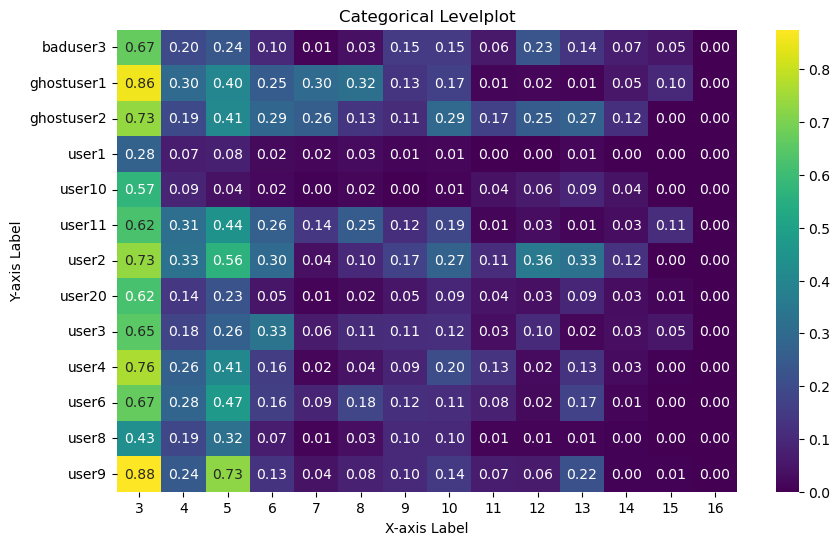

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pivot the dataframe so X and Y are your axes, and Intensity is the value
pivot_df = _df.pivot(index="user", columns="len", values="1-off")

# 2. Create the levelplot/heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_df, cmap="viridis", annot=True, fmt=".2f") # Adjust fmt based on your numbers

# 3. Add labels and display
plt.xlabel("X-axis Label")
plt.ylabel("Y-axis Label")
plt.title("Categorical Levelplot")
plt.show()

# (3) Pick a redteam PID with several files

Find other PIDs with several hits


In [13]:
process = pd.read_parquet("Data/process_uber_summary.parquet")
process.shape


(1772966, 135)

In [14]:
red = process[['pid_hash','red_team']]
red[red['red_team']==1]
red = red.set_index('pid_hash')['red_team'].to_dict()


In [15]:
## baduser3
badfiles = files[files['pid_hash'] == 'BB8D51837C4CD278B09A83D92341D00B']['filename'].tolist()
print(badfiles[0])
len(badfiles)


c:\users\baduser3\documents\desktop.ini


60

In [16]:
## badfiles -- use as templates
_ = [f.split('\\') for f in badfiles]
print('first item:',Counter([s[0] for s in _]))
badfiles = [s[1:] for s in _ if len(s)>2]
Counter([len(s) for s in badfiles])


first item: Counter({'c:': 60})


Counter({4: 16, 8: 9, 10: 9, 7: 8, 3: 6, 9: 6, 5: 3, 6: 1, 2: 1})

In [17]:
_ctr = Counter(files['pid_hash'])
candidates = [str(k) for k, c in _ctr.items() if 55 <= c <= 65]
len(candidates)


115

In [18]:
_dct = []
for c in candidates:
    if red.get(c,1) == 0:
        c_files = files[files['pid_hash'] == c]['filename'].tolist()
        _ = [f.split('\\') for f in c_files]
        c_files = [s[1:] for s in _ if (len(s)>2) and (len(s)<12)]
        _dct.append( (c,c_files) )  

In [19]:
TreeData = []
for s in badfiles:
    sg = ig.Graph.TupleList([(i,i+1) for i in range(len(s)-1)], directed=True)
    sg.vs['dir'] = s
    TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))
for (h,c) in _dct:
    for s in c:
        sg = ig.Graph.TupleList([(i,i+1) for i in range(len(s)-1)], directed=True)
        sg.vs['dir'] = s
        TreeData.append(igio.igraph_to_treedata(sg, phi_name='dir'))    
## encode all trees
fast = fm.FastTreePathMatcher()
fast.fit_encoder(TreeData)
enc = [fast.encode_tree(t) for t in TreeData]
len(enc)


4919

In [20]:
L = []
l = len(badfiles)
lens = [len(x[1]) for x in _dct]

for i in range(len(badfiles)):
    gap = l
    for c in range(len(_dct)):
        max_score = 0
        for j in range(lens[c]):
            _, score = fast.predict_encoded(enc[i], enc[j+gap])
            if score>max_score:
                max_score = score
        gap += lens[c]
        if max_score>=3:
            L.append([i,c,int(max_score),len(badfiles[i])])


In [21]:
_df = pd.DataFrame(L, columns=['badfile','candidate','score','max_score'])
_df['ratio'] = _df['score'] / _df['max_score']
_df.sort_values(by='score', ascending=False)


,badfile,candidate,score,max_score,ratio
952,29,27,9,10,0.900000
453,11,24,9,10,0.900000
979,29,85,9,10,0.900000
1686,53,27,9,10,0.900000
1683,53,24,9,10,0.900000
...,...,...,...,...,...
502,12,73,3,8,0.375000
500,12,63,3,8,0.375000
1214,36,63,3,9,0.333333
499,12,62,3,8,0.375000


In [22]:
_ = _df.groupby(by='candidate').sum().sort_values(by='ratio', ascending=False)
top_candidates = _.nlargest(25,'ratio').index.tolist()
_df = _df[_df.candidate.isin(top_candidates)]


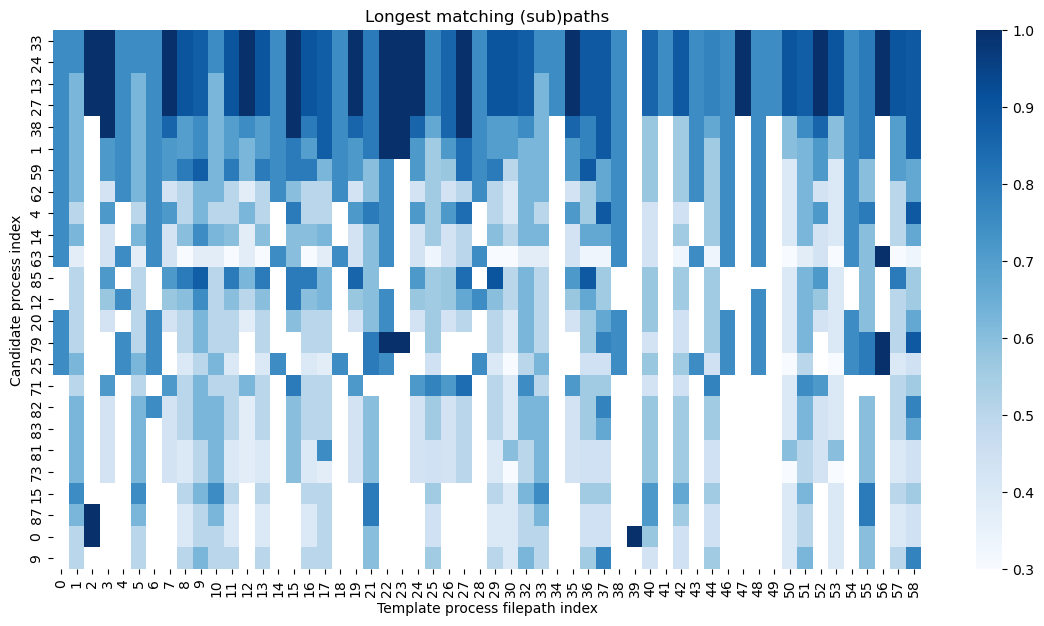

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Pivot the dataframe so X and Y are your axes, and Intensity is the value
pivot_df = _df.pivot(index="candidate", columns="badfile", values="ratio")
_s = _df.groupby(by='candidate').sum()['ratio'].sort_values(ascending=False).index.tolist()
pivot_df = pivot_df.reindex(_s)
# 2. Create the levelplot/heatmap
plt.figure(figsize=(14, 7))
sns.heatmap(pivot_df, cmap="Blues", annot=False)

# 3. Add labels and display
plt.xlabel("Template process filepath index")
plt.ylabel("Candidate process index")
plt.title("Longest matching (sub)paths")
plt.show()


In [24]:
l = [candidates[i] for i in top_candidates[:4]]+['BB8D51837C4CD278B09A83D92341D00B']

process[process['pid_hash'].isin(l)][['pid_hash','red_team','user_name','process_name']]
    


,pid_hash,red_team,user_name,process_name
1575,BB8D51837C4CD278B09A83D92341D00B,1,ACME\baduser3,explorer.exe
207105,D6F14DA9BF7A140A0C517A8F844EDCA5,0,ACME\user9,explorer.exe
254102,6CF200AAC12D00B0705C8CA250728577,0,ACME\user20,code.exe
1227487,C01ECA581033E5FF73A2ECBF975D66AD,0,ACME\grantj,cleanmgr.exe
1434659,8CAE92A5E4D2F934E92FC6E22674E7D2,0,None,taskhostw.exe
